Failed encoding utf-8: 'utf-8' codec can't decode byte 0xa3 in position 16: invalid start byte
Failed encoding utf-8-sig: 'utf-8' codec can't decode byte 0xa3 in position 7092: invalid start byte
Loaded '/content/Stock News Dataset.csv' with encoding=cp1252, shape=(4101, 27)
After combining, shape: (4101, 28)
Label distribution:
 Label
1    2166
0    1935
Name: count, dtype: int64


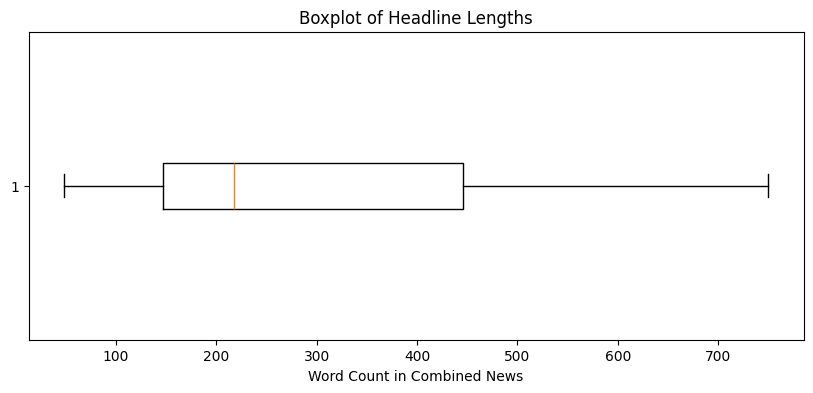

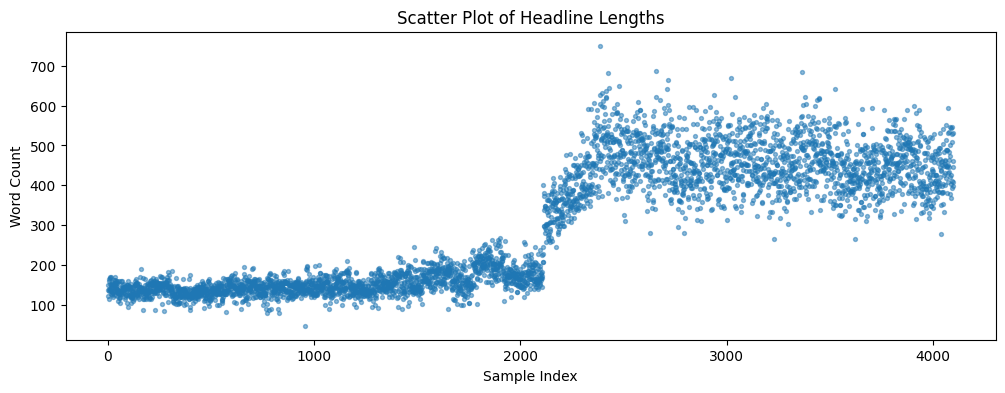

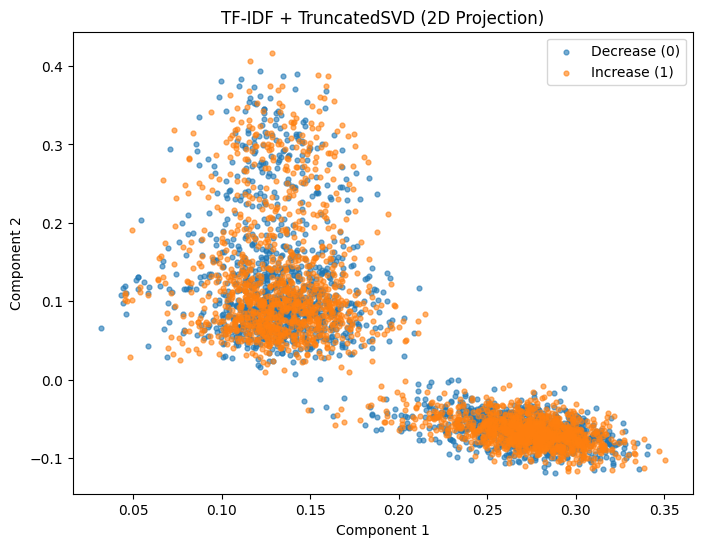

Using device: cpu
Generating DistilBERT embeddings...


100%|██████████| 257/257 [06:30<00:00,  1.52s/it]


Embeddings shape: (4101, 768)

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.4686    0.4625    0.4655       387
           1     0.5262    0.5323    0.5292       434

    accuracy                         0.4994       821
   macro avg     0.4974    0.4974    0.4974       821
weighted avg     0.4990    0.4994    0.4992       821


=== Confusion Matrix (raw numbers) ===
[[179 208]
 [203 231]]


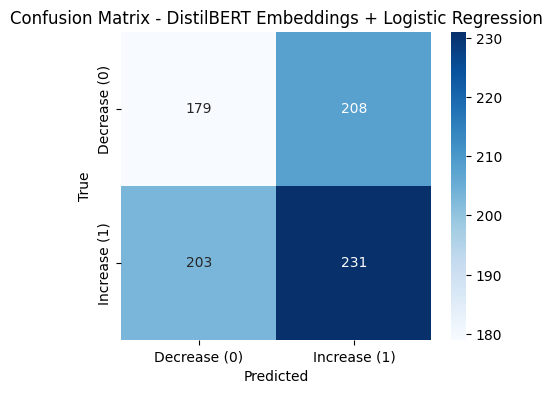

Saved classifier+scaler to 'distilbert_clf.joblib'


100%|██████████| 1/1 [00:00<00:00,  2.01it/s]


Sample: drug decriminalization in portugal decreases number of addicts pounds of silver ...
Prediction: Increase (p_up=0.651)

Sample: megaupload founder defeats us govt attempts to put him back in prison end destru...
Prediction: Decrease (p_up=0.480)

Sample: not just william mtk hungaria celtic rangers fc copenhagen ranieri move puts mak...
Prediction: Increase (p_up=0.741)


In [ ]:
# ======= Colab-ready: install dependencies =======
!pip -q install transformers torch scikit-learn pandas matplotlib seaborn joblib

# ======= Imports =======
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import joblib

import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# ======= 0) Robust CSV load =======
CSV_PATH = "/content/Stock News Dataset.csv"   # adjust path if needed
missing_values = ["?", "N/A", "na", "null", " ", ""]

def load_csv(path):
    for enc in ("utf-8", "utf-8-sig", "cp1252", "latin1"):
        try:
            df = pd.read_csv(path, encoding=enc, na_values=missing_values)
            print(f"Loaded '{path}' with encoding={enc}, shape={df.shape}")
            return df
        except Exception as e:
            print(f"Failed encoding {enc}: {e}")
    raise RuntimeError("Could not read CSV with tried encodings.")

df = load_csv(CSV_PATH)

# ======= 1) Combine headlines =======
headline_cols = [f"Top{i}" for i in range(1, 26)]
present_headline_cols = [c for c in headline_cols if c in df.columns]

if len(present_headline_cols) == 0:
    raise ValueError("Dataset is missing Top1..Top25 headline columns. Found: " + ", ".join(df.columns))

# keep only rows with labels
df['Label'] = df['Label'].astype('float')
df = df.dropna(subset=['Label']).copy()
df['Label'] = df['Label'].astype(int)

# fill missing headlines and combine
df[present_headline_cols] = df[present_headline_cols].fillna("")
df['Combined_News'] = df[present_headline_cols].astype(str).agg(' '.join, axis=1)

print("After combining, shape:", df.shape)
print("Label distribution:\n", df['Label'].value_counts())

# ======= 2) Clean text =======
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['Processed_News'] = df['Combined_News'].apply(clean_text)

# ======= 3) Exploratory Data Analysis (EDA) =======
# Headline lengths
df['headline_length'] = df['Processed_News'].str.split().apply(len)

# Boxplot
plt.figure(figsize=(10,4))
plt.boxplot(df['headline_length'], vert=False)
plt.xlabel("Word Count in Combined News")
plt.title("Boxplot of Headline Lengths")
plt.show()

# Scatter plot
plt.figure(figsize=(12,4))
plt.scatter(range(len(df)), df['headline_length'], alpha=0.5, s=8)
plt.xlabel("Sample Index")
plt.ylabel("Word Count")
plt.title("Scatter Plot of Headline Lengths")
plt.show()

# TF-IDF + SVD 2D visualization
nonempty_mask = df['Processed_News'].str.strip() != ""
sample_texts = df.loc[nonempty_mask, 'Processed_News'].values
if len(sample_texts) >= 2:
    vect = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words="english")
    X_tfidf = vect.fit_transform(sample_texts)
    svd = TruncatedSVD(n_components=2, random_state=42)
    X_2d = svd.fit_transform(X_tfidf)
    labels_viz = df.loc[nonempty_mask, 'Label'].values

    plt.figure(figsize=(8,6))
    mask0 = labels_viz == 0
    mask1 = labels_viz == 1
    plt.scatter(X_2d[mask0,0], X_2d[mask0,1], label="Decrease (0)", alpha=0.6, s=12)
    plt.scatter(X_2d[mask1,0], X_2d[mask1,1], label="Increase (1)", alpha=0.6, s=12)
    plt.legend()
    plt.title("TF-IDF + TruncatedSVD (2D Projection)")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()
else:
    print("Not enough non-empty texts for TF-IDF visualization.")

# ======= 4) DistilBERT Embedding =======
MODEL_NAME = "distilbert-base-uncased"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

def embed_texts(texts, batch_size=16, max_length=64):
    all_embs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]
            enc = tokenizer(batch, padding=True, truncation=True,
                            max_length=max_length, return_tensors="pt")
            enc = {k: v.to(DEVICE) for k,v in enc.items()}
            outputs = model(**enc)
            cls_emb = outputs.last_hidden_state[:,0,:].cpu().numpy()
            all_embs.append(cls_emb)
    return np.vstack(all_embs)

texts = df['Processed_News'].tolist()
print("Generating DistilBERT embeddings...")
X = embed_texts(texts)
y = df['Label'].values
print("Embeddings shape:", X.shape)

# ======= 5) Train/test split =======
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ======= 6) Train classifier =======
clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
clf.fit(X_train_scaled, y_train)

# ======= 7) Evaluate =======
y_pred = clf.predict(X_test_scaled)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("\n=== Confusion Matrix (raw numbers) ===")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Decrease (0)", "Increase (1)"],
            yticklabels=["Decrease (0)", "Increase (1)"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - DistilBERT Embeddings + Logistic Regression")
plt.show()

# ======= 8) Save artifacts =======
joblib.dump({"classifier": clf, "scaler": scaler}, "distilbert_clf.joblib")
print("Saved classifier+scaler to 'distilbert_clf.joblib'")

# ======= 9) Example inference =======
def predict_headlines(headlines):
    clean = [clean_text(h) for h in headlines]
    embs = embed_texts(clean)
    embs_scaled = scaler.transform(embs)
    preds = clf.predict(embs_scaled)
    probs = clf.predict_proba(embs_scaled)[:,1]
    return preds, probs

demo_samples = df['Processed_News'].sample(3, random_state=0).tolist()
preds, probs = predict_headlines(demo_samples)
for txt, p, pr in zip(demo_samples, preds, probs):
    print(f"\nSample: {txt[:80]}...")
    print(f"Prediction: {'Increase' if p==1 else 'Decrease'} (p_up={pr:.3f})")


In [ ]:
# 📌 Corrected code for DistilBERT model

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.optim import AdamW # Corrected import statement
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Load dataset
file_path = "/content/Sentiment_Stock_data.csv"
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the file path.")
    exit()

# 2. Drop unnecessary column and missing values
df = df.drop(columns=["Unnamed: 0"]).dropna()

# 3. Features (X) and Target (y)
X = df["Sentence"].tolist()
y = df["Sentiment"].tolist()

# 4. Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Tokenization and data preparation
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Custom dataset class for PyTorch
class StockDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Tokenize datasets
train_encodings = tokenizer(X_train, truncation=True, padding=True)
test_encodings = tokenizer(X_test, truncation=True, padding=True)

train_dataset = StockDataset(train_encodings, y_train)
test_dataset = StockDataset(test_encodings, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 6. Load pre-trained DistilBERT model
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)
model.to(device)

# 7. Fine-tuning the model
optimizer = AdamW(model.parameters(), lr=5e-5)
model.train()

print("\nStarting model fine-tuning...")
for epoch in range(1):  # Fine-tune for 3 epochs
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(
            input_ids, attention_mask=attention_mask, labels=labels
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

model.eval()

# 8. Predictions and evaluation
y_pred = []
y_true = []

print("\nMaking predictions on test data...")
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1)

        y_pred.extend(predictions.cpu().tolist())
        y_true.extend(labels.cpu().tolist())

# 9. Evaluation Metrics
print("\n✅ Model Evaluation\n")
print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, digits=3))

# 10. Confusion Matrix (heatmap)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Decrease (0)", "Increase (1)"],
    yticklabels=["Decrease (0)", "Increase (1)"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Using device: cpu


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting model fine-tuning...
Epoch 1, Loss: 0.6935
Epoch 1, Loss: 0.7017
Epoch 1, Loss: 0.6839
Epoch 1, Loss: 0.6903
Epoch 1, Loss: 0.7255
Epoch 1, Loss: 0.6845
Epoch 1, Loss: 0.7060
Epoch 1, Loss: 0.7097
Epoch 1, Loss: 0.6003
Epoch 1, Loss: 0.7234
Epoch 1, Loss: 0.6328
Epoch 1, Loss: 0.6805
Epoch 1, Loss: 0.7310
Epoch 1, Loss: 0.7299
Epoch 1, Loss: 0.7444
Epoch 1, Loss: 0.7214
Epoch 1, Loss: 0.7275
Epoch 1, Loss: 0.6902
Epoch 1, Loss: 0.7035
Epoch 1, Loss: 0.6800
Epoch 1, Loss: 0.6711
Epoch 1, Loss: 0.6850
Epoch 1, Loss: 0.6796
Epoch 1, Loss: 0.6513
Epoch 1, Loss: 0.7091
Epoch 1, Loss: 0.6890
Epoch 1, Loss: 0.6313
Epoch 1, Loss: 0.7342
Epoch 1, Loss: 0.6991
Epoch 1, Loss: 0.7148
Epoch 1, Loss: 0.6785
Epoch 1, Loss: 0.7425
Epoch 1, Loss: 0.7471
Epoch 1, Loss: 0.6556
Epoch 1, Loss: 0.6676
Epoch 1, Loss: 0.6824
Epoch 1, Loss: 0.6986
Epoch 1, Loss: 0.7095
Epoch 1, Loss: 0.7094
Epoch 1, Loss: 0.6800
Epoch 1, Loss: 0.7078
Epoch 1, Loss: 0.6587
Epoch 1, Loss: 0.7267
Epoch 1, Loss: 0.7734
E